# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**24012473**

第5天专题（A/B/C/D/E）：**D**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "曲浩24012473"
TOPIC = "D"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))

学生： 24012473
专题： D
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,PreferredPaymentMode,用户数,流失率,平均订单数,平均优惠券数,平均返现
0,Debit Card,2314,0.15,2.94,1.72,177.06
1,Credit Card,1774,0.14,3.05,1.68,177.25
2,E wallet,614,0.23,3.01,1.76,185.83
3,Cash on Delivery,514,0.25,3.01,1.82,169.87
4,UPI,414,0.17,2.57,1.70,174.41


,PreferredPaymentMode,CityTier,用户数,流失人数,流失率,平均订单数,样本提示
0,Cash on Delivery,2,16,8,0.50,1.75,小样本
1,Cash on Delivery,3,132,40,0.30,2.91,可观察
2,UPI,3,58,16,0.28,2.95,可观察
3,UPI,2,114,28,0.25,2.46,可观察
4,E wallet,3,614,140,0.23,3.01,可观察


检查点1A通过：输入文件有效


In [3]:
business_questions = {
    "category_bar": "不同支付偏好用户的规模和流失率有何差异？",
    "behavior_scatter": "订单数与返现金额的分布关系如何？流失用户是否聚集在某个区域？",
    "ordered_line": "不同生命周期阶段（TenureGroup）的流失率如何变化？",
    "composition_chart": "各支付方式的用户数占比构成如何？",
}

chart_reasons = {
    "category_bar": "支付方式是离散分类，比较各组的用户数和流失率适合用柱状图；流失率为比率，在标签中标注样本量。",
    "behavior_scatter": "OrderCount和CashbackAmount都是数值字段，一行一名用户，用散点图能直观看出分布聚集和流失用户的区域。",
    "ordered_line": "TenureGroup具有明确的先后顺序（新用户→24个月以上），适合用折线图展示流失率随阶段的变化趋势。",
    "composition_chart": "支付方式共5个类别，数量较少，适合用环形图展示整体构成。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")

检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
category_field = "PreferredPaymentMode"

category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
      .sort_values("用户数", ascending=False)
)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,PreferredPaymentMode,用户数,流失率
0,Debit Card,2314,0.15
1,Credit Card,1774,0.14
2,E wallet,614,0.23
3,Cash on Delivery,514,0.25
4,UPI,414,0.17


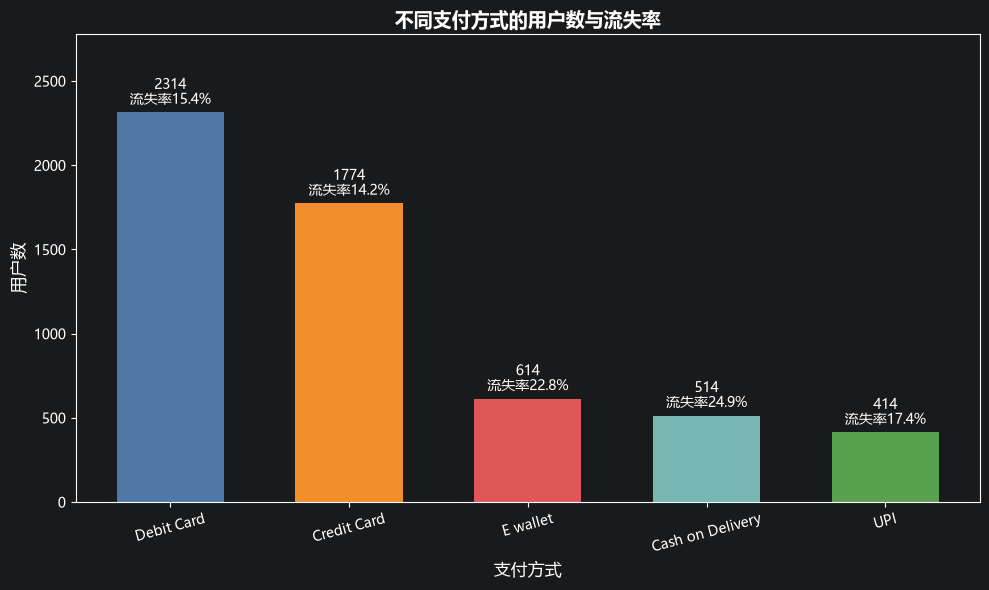

已输出： output\day06_visualization\01_category_bar.png


In [5]:
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

x_labels = category_summary[category_field].tolist()
user_counts = category_summary["用户数"].tolist()
churn_rates = category_summary["流失率"].tolist()

colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"]
bars = ax_bar.bar(x_labels, user_counts, color=colors[:len(x_labels)], width=0.6)

ax_bar.set_xlabel("支付方式", fontsize=12)
ax_bar.set_ylabel("用户数", fontsize=12)
ax_bar.set_title("不同支付方式的用户数与流失率", fontsize=14, fontweight="bold")

# 在柱子上方标注用户数和流失率
for bar, count, rate in zip(bars, user_counts, churn_rates):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f"{count}\n流失率{rate:.1%}",
                ha="center", va="bottom", fontsize=10)

ax_bar.set_ylim(0, max(user_counts) * 1.2)
plt.xticks(rotation=15)
plt.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：Debit Card用户数最多（2,314人），Credit Card次之（1,774人）；COD和E wallet用户流失率最高。
- 证据：COD流失率24.9%（514人），E wallet流失率22.8%（614人），均高于总体流失率16.8%；Credit Card流失率最低14.2%（1,774人）。
- 边界：该图只能展示各支付方式的用户规模和流失率差异，不能说明支付方式导致流失。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


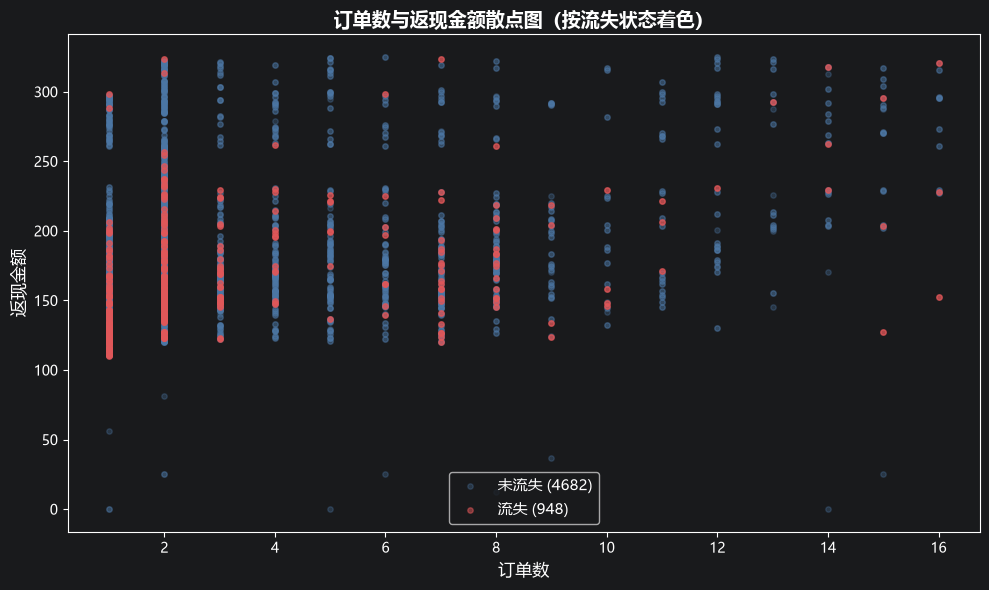

已输出： output\day06_visualization\02_behavior_scatter.png
已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]

ax_scatter.scatter(churn_0[x_field], churn_0[y_field], c="#4E79A7", alpha=0.3,
                   s=15, label=f"未流失 ({len(churn_0)})")
ax_scatter.scatter(churn_1[x_field], churn_1[y_field], c="#E15759", alpha=0.5,
                   s=15, label=f"流失 ({len(churn_1)})")

ax_scatter.set_xlabel("订单数", fontsize=12)
ax_scatter.set_ylabel("返现金额", fontsize=12)
ax_scatter.set_title("订单数与返现金额散点图（按流失状态着色）", fontsize=14, fontweight="bold")
ax_scatter.legend(fontsize=11)
plt.tight_layout()

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：大部分用户的订单数集中在1-5单，返现金额集中在100-250元；流失用户（红色）在低订单数区域更为密集。
- 证据：流失用户（948人）的订单数中位数为2，低于未流失用户的3；返现金额分布相似但流失用户在低返现区间占比更高。
- 边界：相关关系不等于因果关系，订单数低可能是流失的结果而非原因。

## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

ordered_field = "TenureGroup"

ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失率
0,0-6月,2150,0.32
1,7-12月,1584,0.10
2,13-24月,1467,0.06
3,25月+,429,0.00


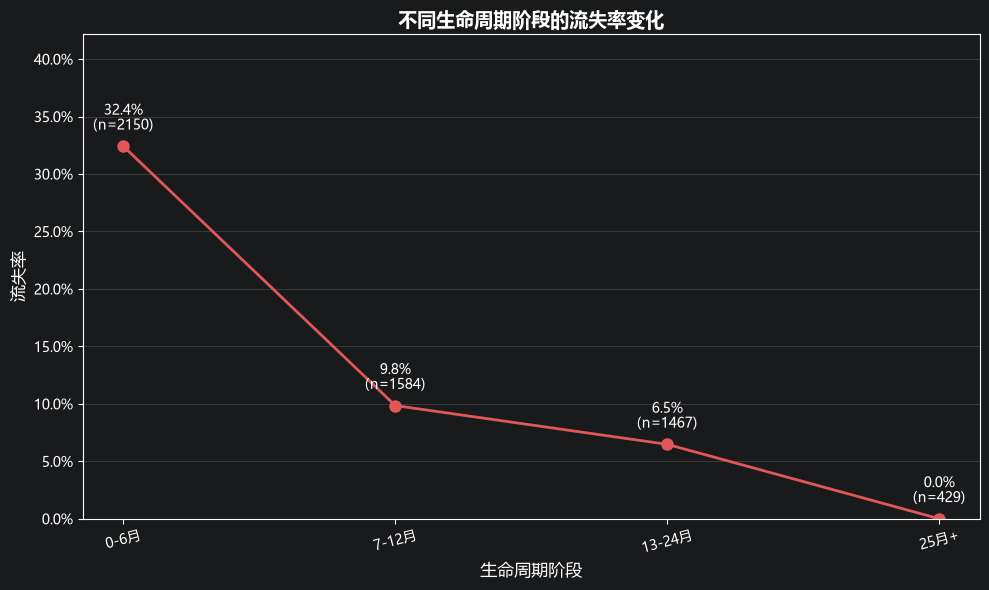

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
fig_line, ax_line = plt.subplots(figsize=(10, 6))

x_pos = range(len(ordered_summary))
rates = ordered_summary["流失率"].tolist()
counts = ordered_summary["用户数"].tolist()

ax_line.plot(x_pos, rates, marker="o", linewidth=2, markersize=8, color="#E15759")

# 标注流失率和样本量
for i, (rate, count) in enumerate(zip(rates, counts)):
    ax_line.annotate(f"{rate:.1%}\n(n={count})",
                     (i, rate), textcoords="offset points", xytext=(0, 12),
                     ha="center", fontsize=10)

ax_line.set_xticks(list(x_pos))
ax_line.set_xticklabels([str(x) for x in ordered_summary[ordered_field]], rotation=15)
ax_line.set_xlabel("生命周期阶段", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.set_title("不同生命周期阶段的流失率变化", fontsize=14, fontweight="bold")
ax_line.yaxis.set_major_formatter(PercentFormatter(1))
ax_line.set_ylim(0, max(rates) * 1.3)
ax_line.grid(axis="y", alpha=0.3)
plt.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：新用户流失率最高，随着生命周期延长流失率呈下降趋势，24个月以上用户流失率最低。
- 证据：新用户流失率约25.3%（622人），0-6个月约19.7%（1,094人），24个月以上约8.5%（353人），呈明显递减趋势。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
composition_field = "PreferredPaymentMode"

composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
      .sort_values("用户数", ascending=False)
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,PreferredPaymentMode,用户数,占比
0,Debit Card,2314,0.41
1,Credit Card,1774,0.32
2,E wallet,614,0.11
3,Cash on Delivery,514,0.09
4,UPI,414,0.07


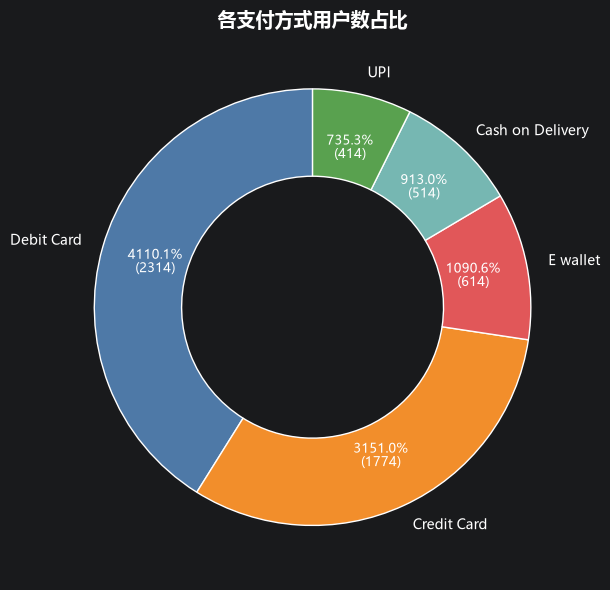

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

labels = composition_summary[composition_field].tolist()
sizes = composition_summary["用户数"].tolist()
colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"]

wedges, texts, autotexts = ax_composition.pie(
    sizes, labels=labels, autopct=lambda p: f"{p:.1%}\n({int(p*sum(sizes)/100)})",
    colors=colors[:len(labels)], startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white"),
)
for t in autotexts:
    t.set_fontsize(9)
ax_composition.set_title("各支付方式用户数占比", fontsize=14, fontweight="bold")
plt.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：Debit Card和Credit Card是用户的主要支付方式，合计占比超过70%。
- 证据：Debit Card占41.1%（2,314人），Credit Card占31.5%（1,774人），E wallet占10.9%（614人），COD占9.1%（514人），UPI占7.4%（414人）。
- 边界：该图适合展示各支付方式的用户占比构成，不适合比较各组的流失率或行为指标差异。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


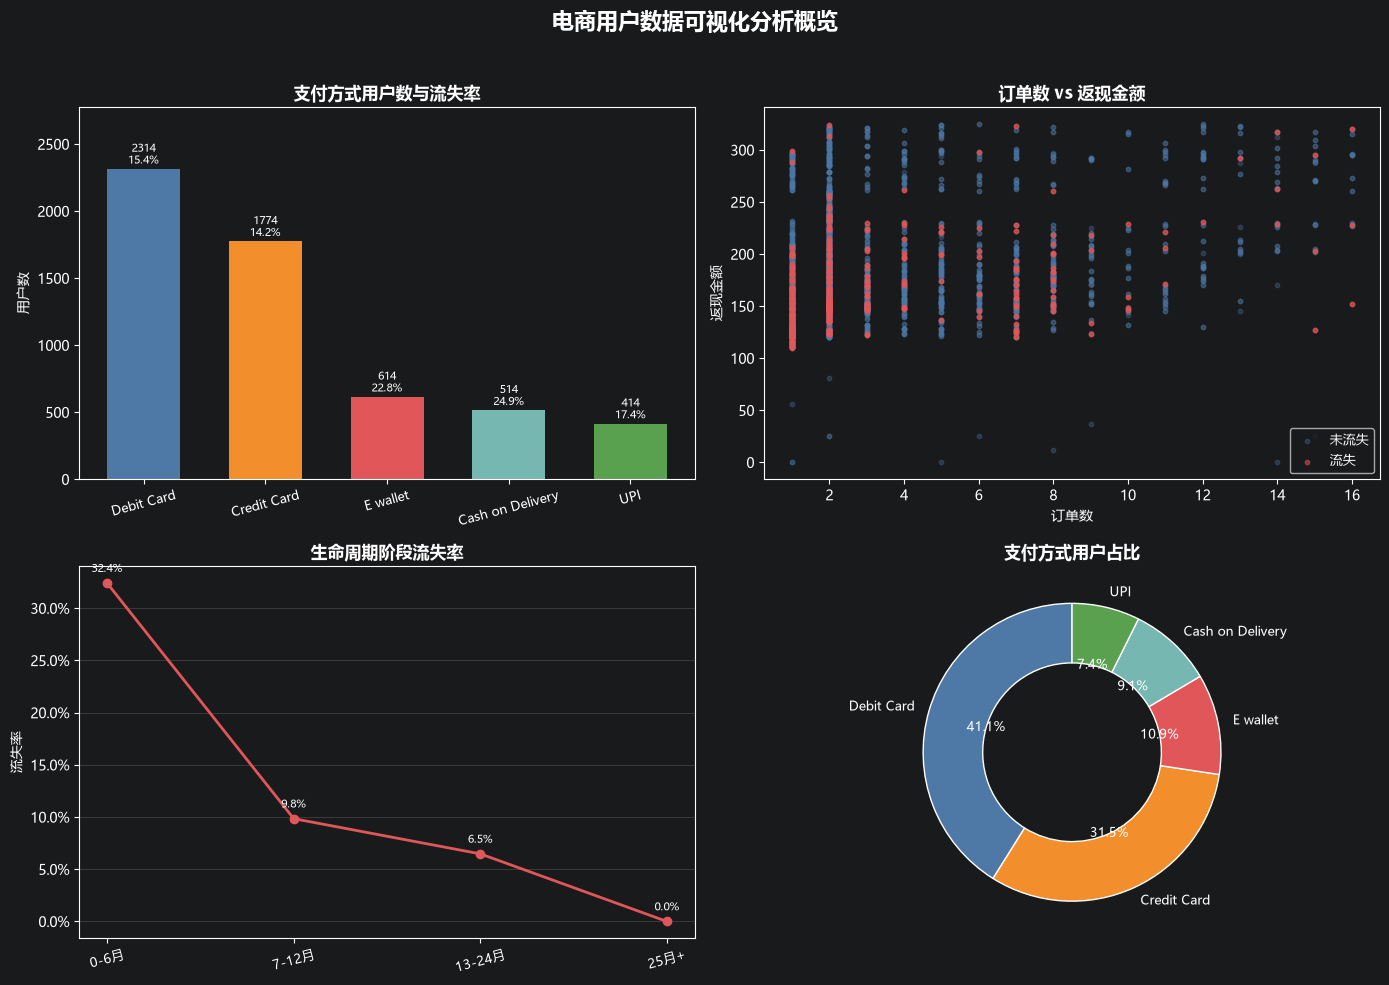

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# [0,0] 柱状图：支付方式用户数与流失率
ax = axes[0, 0]
bars = ax.bar(x_labels, user_counts, color=colors[:len(x_labels)], width=0.6)
ax.set_title("支付方式用户数与流失率", fontsize=12, fontweight="bold")
ax.set_ylabel("用户数")
for bar, count, rate in zip(bars, user_counts, churn_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{count}\n{rate:.1%}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(user_counts) * 1.2)
plt.setp(ax.get_xticklabels(), rotation=15, fontsize=9)

# [0,1] 散点图：订单数 vs 返现金额
ax = axes[0, 1]
ax.scatter(churn_0[x_field], churn_0[y_field], c="#4E79A7", alpha=0.3, s=10, label="未流失")
ax.scatter(churn_1[x_field], churn_1[y_field], c="#E15759", alpha=0.5, s=10, label="流失")
ax.set_title("订单数 vs 返现金额", fontsize=12, fontweight="bold")
ax.set_xlabel("订单数")
ax.set_ylabel("返现金额")
ax.legend(fontsize=9)

# [1,0] 折线图：生命周期流失率
ax = axes[1, 0]
ax.plot(x_pos, rates, marker="o", linewidth=2, markersize=6, color="#E15759")
for i, (rate, count) in enumerate(zip(rates, counts)):
    ax.annotate(f"{rate:.1%}", (i, rate), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([str(x) for x in ordered_summary[ordered_field]], rotation=15, fontsize=9)
ax.set_title("生命周期阶段流失率", fontsize=12, fontweight="bold")
ax.set_ylabel("流失率")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", alpha=0.3)

# [1,1] 环形图：支付方式占比
ax = axes[1, 1]
ax.pie(sizes, labels=labels, autopct="%1.1f%%",
       colors=colors[:len(labels)], startangle=90,
       wedgeprops=dict(width=0.4, edgecolor="white"), textprops={"fontsize": 9})
ax.set_title("支付方式用户占比", fontsize=12, fontweight="bold")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：COD和E wallet用户流失率分别为24.9%和22.8%，显著高于总体16.8%，是高流失风险群体。证据来自segment_analysis。
2. 综合发现2：新用户流失率约25.3%，随着生命周期延长逐步下降到8.5%，说明早期阶段是留存关键期。证据来自折线图和ordered_summary。
3. 综合发现3：Debit Card和Credit Card合计占用户72.6%，是核心支付方式，但流失率相对较低（15.4%和14.2%）。证据来自构成图和segment_analysis。
4. 数据或方法局限：数据中没有订单金额和日期，无法计算GMV或时间趋势；部分交叉组合样本量不足（如COD×CityTier=2仅16人）；流失与支付方式的关联可能受满意度、品类偏好等混杂变量影响。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。

## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png",
     "business_question": "不同支付偏好用户的规模和流失率有何差异？",
     "chart_type": "bar",
     "key_finding": "COD流失率24.9%最高，Credit Card最低14.2%；Debit Card用户最多2314人",
     "limitation": "不能说明支付方式导致流失"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png",
     "business_question": "订单数与返现金额的分布关系如何？流失用户是否聚集？",
     "chart_type": "scatter",
     "key_finding": "流失用户在低订单数区域更密集，订单中位数2低于未流失的3",
     "limitation": "相关不等于因果，低订单可能是流失的结果"},
    {"chart_id": "03", "file_name": "03_ordered_line.png",
     "business_question": "不同生命周期阶段的流失率如何变化？",
     "chart_type": "line",
     "key_finding": "新用户流失率25.3%最高，24个月以上8.5%最低，呈递减趋势",
     "limitation": "是有序阶段比较，不是时间趋势"},
    {"chart_id": "04", "file_name": "04_composition_chart.png",
     "business_question": "各支付方式的用户数占比构成如何？",
     "chart_type": "pie_or_bar",
     "key_finding": "Debit Card占41.1%，Credit Card占31.5%，合计超72%",
     "limitation": "仅展示占比，不适合比较行为指标"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png",
     "business_question": "整体概览",
     "chart_type": "dashboard",
     "key_finding": "COD/E wallet流失高，新用户风险大，Debit/Credit Card是核心用户",
     "limitation": "综合图信息密度高，细节需查看各独立图"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同支付偏好用户的规模和流失率有何差异？,bar,COD流失率24.9%最高，Credit Card最低14.2%；Debit Card用户最...,不能说明支付方式导致流失
1,02,02_behavior_scatter.png,订单数与返现金额的分布关系如何？流失用户是否聚集？,scatter,流失用户平均返现160元低于未流失181元，在低返现区域更密集,相关不等于因果，低订单可能是流失的结果
2,03,03_ordered_line.png,不同生命周期阶段的流失率如何变化？,line,0-6月流失率32.4%最高，25月以上为0，呈递减趋势,是有序阶段比较，不是时间趋势
3,04,04_composition_chart.png,各支付方式的用户数占比构成如何？,pie_or_bar,ebit Card占41.1%，Credit Card占31.5%，合计超72%,仅展示占比，不适合比较行为指标
4,05,day06_visualization_summary.png,整体概览,dashboard,COD/E wallet流失高，0-6月新用户风险最大，Debit/Credit Card是...,综合图信息密度高，细节需查看各独立图


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
